# Fare Prediction — Model Training
This notebook trains and compares two regression models — **Linear Regression** and **Random Forest Regressor** — to predict ride fares.

**Workflow:**
1. Load data
2. Clean up unused columns
3. Detect outliers
4. Remove outliers
5. Train/test split
6. Train & evaluate Linear Regression
7. Train & evaluate Random Forest
8. Compare models & sample prediction

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load Data

In [25]:
data = pd.read_csv("../data/processed_data.csv")
data

,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Fare (Target),...,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
0,20.81,64.6,0,0,1,4,0,0,0.0,749,...,False,False,False,True,False,False,False,False,True,False
1,9.58,40.8,0,0,3,1,1,0,0.0,811,...,False,False,True,False,False,False,False,False,False,True
2,5.36,15.4,1,0,1,2,1,0,4.0,30,...,False,False,False,False,False,False,True,False,True,False
3,5.00,25.3,3,1,3,1,1,0,0.0,1243,...,False,False,False,True,False,False,False,False,True,False
4,18.14,41.8,0,0,0,1,0,0,0.0,30,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5787,11.01,47.6,1,0,2,2,0,0,1.0,1104,...,False,True,False,False,False,False,False,False,True,False
5788,7.53,14.5,5,3,1,2,0,0,2.0,897,...,True,False,True,False,False,False,False,False,True,False
5789,5.60,10.9,0,0,0,2,1,0,3.0,30,...,False,False,False,False,False,True,False,False,True,False
5790,4.78,21.0,3,1,1,0,0,0,2.0,1320,...,False,False,False,False,True,False,False,False,True,False


## 3. Drop Unwanted Columns
`Estimated Duration (min)` and `Weather Condition` are not used as model features, so they are dropped here.

In [3]:
data = data.drop(columns=[
    'Estimated Duration (min)',
    'Weather Condition'
])

data.dtypes

Distance (km)                       float64
Rainfall Intensity                    int64
Traffic Level                         int64
Temperature Level                     int64
Holiday                               int64
Day Type                              int64
Number of Stops Added               float64
Fare (Target)                         int64
Vehicle Type_Bike                      bool
Vehicle Type_Black                     bool
Vehicle Type_Comfort                   bool
Vehicle Type_Go                        bool
Vehicle Type_Mini                      bool
Vehicle Type_Pool                      bool
Vehicle Type_Premium                   bool
Vehicle Type_SUV                       bool
Vehicle Type_Sedan                     bool
Vehicle Type_XL                        bool
Road Type_Expressway                   bool
Road Type_Highway                      bool
Road Type_Rural Road                   bool
Pickup Area Type_Bus Stand             bool
Pickup Area Type_College        

## 4. Outlier Detection
Inspect the `Distance (km)` column for extreme values using summary statistics, percentiles, and the largest values in the data.

In [21]:
print(data['Distance (km)'].describe())

print(
    data['Distance (km)'].quantile([0.95, 0.99, 0.995])
)

count    5792.000000
mean       29.632246
std        51.050134
min         1.000000
25%         7.260000
50%        13.250000
75%        22.080000
max       385.940000
Name: Distance (km), dtype: float64
0.950    161.8870
0.990    246.6088
0.995    284.9659
Name: Distance (km), dtype: float64


In [22]:
data.sort_values(
    by='Distance (km)',
    ascending=False
).head(10)

,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Fare (Target),...,Drop Area Type_Residential,Time Slot_Evening Rush,Time Slot_Late Night,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday
1582,385.94,376.5,1,0,0,3,0,0,1.0,9447,...,False,False,False,False,True,False,False,False,True,False
4012,383.44,577.7,1,0,2,3,1,0,3.0,6521,...,False,False,False,False,False,False,False,False,False,False
2593,382.30,374.5,1,0,0,4,0,1,2.0,13576,...,False,False,False,False,True,False,False,False,True,False
3222,370.02,341.6,0,0,0,3,0,0,0.0,8720,...,False,False,False,False,False,False,True,False,True,False
5499,364.94,336.9,0,0,0,3,0,1,0.0,6820,...,False,False,False,False,False,True,False,False,True,False
2624,363.93,516.8,1,0,2,3,0,0,0.0,6893,...,False,False,False,False,True,False,False,False,True,False
10,363.93,544.0,1,0,2,3,0,0,0.0,12532,...,False,False,False,False,True,False,False,False,True,False
2443,359.26,419.7,1,0,1,4,1,0,6.0,7290,...,False,False,False,False,False,False,False,False,True,False
68,356.71,506.6,0,0,2,4,0,0,0.0,9377,...,True,False,False,False,True,False,False,False,True,False
3518,355.79,553.5,5,3,1,1,0,0,1.0,22674,...,False,False,False,True,False,False,False,False,True,False


## 5. Outlier Removal
Based on the inspection above, rides with a `Distance (km)` greater than 200 are treated as outliers and removed.

In [26]:
data = data[data['Distance (km)'] <= 380]
data.shape

(5789, 50)

## 6. Train / Test Split

In [33]:
X = data.drop(columns=['Fare (Target)'])
y = data['Fare (Target)']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4631, 49)
X_test: (1158, 49)
y_train: (4631,)
y_test: (1158,)


## 7. Model 1 — Linear Regression

In [35]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

### 7.1 Linear Regression — Evaluation Metrics

In [36]:
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, lr_pred))

train_pred = lr_model.predict(X_train)
print("\nTrain R2:", r2_score(y_train, train_pred))
print("Test R2 :", r2_score(y_test, lr_pred))

MAE : 457.292365638022
MSE : 609946.4742712916
RMSE: 780.9907005024398
R2 Score: 0.7870247897994519

Train R2: 0.7745170415933021
Test R2 : 0.7870247897994519


### 7.2 Linear Regression — Residual Analysis
Look at the rows with the largest prediction errors to understand where the model struggles.

In [37]:
residuals = y_test - lr_pred

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": lr_pred,
    "Absolute Error": abs(residuals)
}).reset_index(drop=True)

error_df.sort_values(by="Absolute Error", ascending=False).head(10)

,Actual,Predicted,Absolute Error
729,22674,9432.974205,13241.025795
1040,12538,6139.516990,6398.483010
1121,12867,8301.087713,4565.912287
497,9556,5225.227049,4330.772951
556,8185,4138.446563,4046.553437
833,9151,5705.843002,3445.156998
145,8509,5165.280658,3343.719342
1074,3764,7031.770050,3267.770050
641,8056,5180.318325,2875.681675
697,2854,5678.412085,2824.412085


In [38]:
# Number of predictions with an absolute error greater than 2000
(error_df["Absolute Error"] > 2000).sum()

np.int64(20)

In [39]:
X_test_reset = X_test.reset_index(drop=True)

high_error_idx = error_df.sort_values(
    by="Absolute Error",
    ascending=False
).head(20).index

high_error_rows = pd.concat(
    [X_test_reset.loc[high_error_idx], error_df.loc[high_error_idx]],
    axis=1
)

high_error_rows

,Distance (km),Estimated Duration (min),Weather Condition,Rainfall Intensity,Traffic Level,Temperature Level,Holiday,Day Type,Number of Stops Added,Vehicle Type_Bike,...,Time Slot_Midday,Time Slot_Morning,Time Slot_Morning Rush,Time Slot_Night,Busy Day_Major Event,Busy Day_Normal,Busy Day_Public Holiday,Actual,Predicted,Absolute Error
729,355.79,553.5,5,3,1,1,0,0,1.0,False,...,True,False,False,False,False,True,False,22674,9432.974205,13241.025795
1040,151.74,255.0,3,2,2,1,0,1,1.0,False,...,False,False,False,False,True,False,False,12538,6139.516990,6398.483010
1121,280.34,766.7,4,2,3,1,0,0,0.0,False,...,False,False,False,False,False,True,False,12867,8301.087713,4565.912287
497,168.65,189.5,4,2,1,1,1,1,1.0,False,...,False,False,False,True,False,True,False,9556,5225.227049,4330.772951
556,137.71,426.0,0,0,1,3,1,1,0.0,False,...,False,False,False,False,False,True,False,8185,4138.446563,4046.553437
833,149.52,331.1,5,3,3,2,1,1,0.0,False,...,False,False,False,False,False,True,False,9151,5705.843002,3445.156998
145,147.35,692.5,0,0,3,1,1,0,0.0,False,...,False,False,False,False,True,False,False,8509,5165.280658,3343.719342
1074,350.66,501.0,0,0,2,1,0,1,2.0,True,...,False,False,True,False,False,True,False,3764,7031.770050,3267.770050
641,156.40,348.2,2,0,3,2,1,1,3.0,False,...,False,False,True,False,False,True,False,8056,5180.318325,2875.681675
697,281.72,401.6,0,0,2,1,0,0,1.0,True,...,False,False,False,False,False,True,False,2854,5678.412085,2824.412085


In [ ]:
high_error_rows.to_csv("high_error_rows.csv", index=False)

### 7.3 Linear Regression — Residual Plot

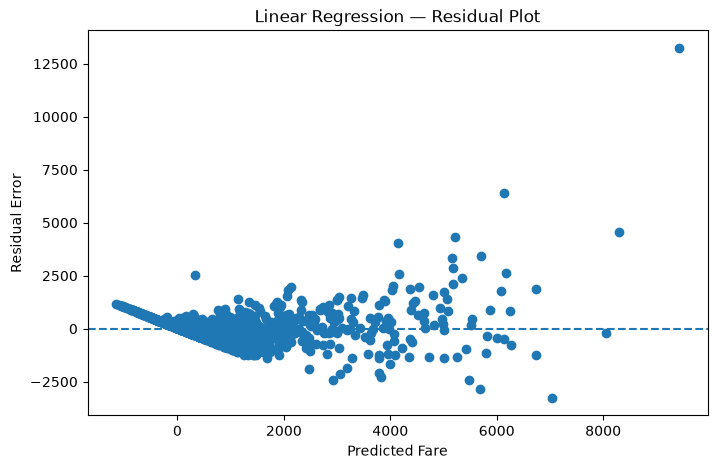

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(lr_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Fare")
plt.ylabel("Residual Error")
plt.title("Linear Regression — Residual Plot")
plt.show()

### 7.4 Distance vs Fare
A quick visual check of the relationship between distance and fare after outlier removal.

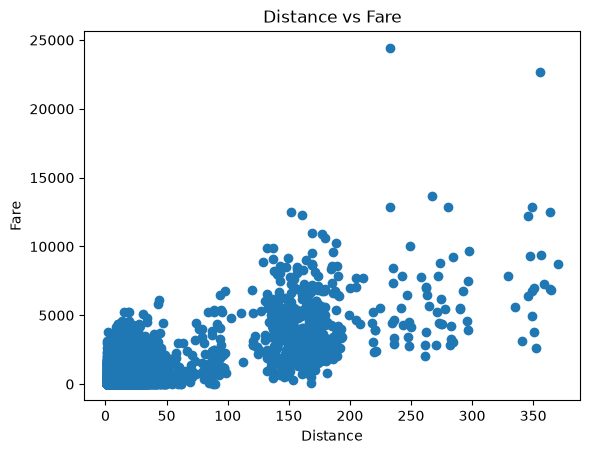

In [41]:
plt.scatter(data['Distance (km)'], data['Fare (Target)'])
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Distance vs Fare")
plt.show()

## 8. Model 2 — Random Forest Regressor

In [42]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

### 8.1 Random Forest — Evaluation Metrics

In [43]:
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred) ** 0.5)
print("R2 Score:", r2_score(y_test, rf_pred))

MAE : 291.432006044905
RMSE: 633.2828394064895
R2 Score: 0.8599662336407713


## 9. Model Comparison

In [44]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, lr_pred) ** 0.5,
        mean_squared_error(y_test, rf_pred) ** 0.5
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,457.292366,780.990701,0.787025
1,Random Forest,291.432006,633.282839,0.859966


## 10. Sample Prediction (Linear Regression)
Build a single sample ride and predict its fare using the trained Linear Regression model.

In [50]:
# Create a row with all features initialized as 0
bike_prediction = pd.DataFrame(
    0,
    index=[0],
    columns=X_train.columns
)

# Numeric features
bike_prediction['Distance (km)'] = 15

# Normal conditions
bike_prediction['Rainfall Intensity'] = 0       # No Rain
bike_prediction['Traffic Level'] = 0            # Low
bike_prediction['Temperature Level'] = 1        # Pleasant
bike_prediction['Holiday'] = 0                  # No Holiday
bike_prediction['Day Type'] = 0                 # Weekday
bike_prediction['Number of Stops Added'] = 0

# Normal categorical values
bike_prediction['Pickup Area Type_Residential'] = 1
bike_prediction['Drop Area Type_Residential'] = 1
bike_prediction['Time Slot_Midday'] = 1
bike_prediction['Busy Day_Normal'] = 1

# Vehicle type = Bike
bike_prediction['Vehicle Type_Bike'] = 1

# Prediction
predicted_bike_fare = rf_model.predict(bike_prediction)

print("Predicted Bike Fare for 15 km: ₹",predicted_bike_fare)

Predicted Bike Fare for 15 km: ₹ [30.]
